# 延迟交付对客户满意度的影响（PSM）


## 一、背景
市场的本质在于其**匹配卖家与客户**的能力。卖家希望展示并销售其产品/服务，客户则在需要时精准获得所需。  
然而，如果没有关键的最后一步——**交付**——这种连接是不完整的。  
交付消除了购买体验中的摩擦，使客户可以跳过到店，**将订单直送到家门口**。但这种便利取决于一个核心条件：**订单按客户期望时间送达**。一旦**交付延迟**，客户满意度就会受到影响。

## 1、延迟交付与评级
- **延迟交付**：订单在**预期交付日期之后**送达。  
- 该交付窗口承载着平台对客户的**时间承诺**，与客户评级密切相关。

## 2、延迟交付对客户评级有何影响？
> 研究问题：比较**同一订单**在**按时交付**与**延迟交付**时的客户评分差异。

### 2.1 理想设计：A/B 测试
- 处理（Treatment）：延迟交付，`T = 1`  
- 对照（Control）：准时交付，`T = 0`

### 2.2 现实限制
- 我们**无法完全控制**对照组中的所有客户都按时交付。  
- **主动制造延迟**会带来糟糕体验，存在伦理与业务风险。

### 2.3 实际做法
基于以上限制，转向**因果推理**，采用**倾向得分匹配（Propensity Score Matching, PSM）**来估计延迟对客户评级的**因果影响**。

## 二、数据初始化

In [2]:
import sys
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use('ggplot')
import seaborn as sns
import networkx as nx 
import graphviz 
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from dowhy import CausalModel
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [3]:
def check_for_dataset_balance(control_idx, treatment_idx, estimate_type):
    """
    检查匹配后的对照组与处理组在协变量上的平衡性。

    根据估计类型（'att' 或 'atc'），选取对应索引的样本，
    给两组数据打上标记并合并，最后返回各协变量的分组描述性统计。
    """

    if estimate_type == 'att':
        control_df = control.iloc[control_idx][covariates]
        treatment_df = treated.loc[treatment_idx][covariates]
        control_df['is_treatment'] = 0
        treatment_df['is_treatment'] = 1
        matched_df = pd.concat([control_df, treatment_df])
        return matched_df.groupby('is_treatment').describe().T
    elif estimate_type == 'atc':
        control_df = control.loc[control_idx][covariates]
        treatment_df = treated.iloc[treatment_idx][covariates]
        control_df['is_treatment'] = 0
        treatment_df['is_treatment'] = 1
        matched_df = pd.concat([control_df, treatment_df])
        return matched_df.groupby('is_treatment').describe().T
        
df = pd.read_csv("/Users/liyanping/Desktop/GitHub-DataScience/因果推断/PSM-DID/顾客满意度的因果分析/Data/data.csv")
df.shape

## 三、预处理与数据定义

In [4]:
nodes_list = [
'Rating',
'product_category_name_encoded',
'freight_value',
'distance_km',
'month',
'is_delivery_late'
]

df[nodes_list].isnull().sum()

# 确定协变量、干预和结果
covariates = ['product_category_name_encoded', 'month', 'product_size', 'freight_value', 'distance_km']
treatment = 'is_delivery_late'
outcome = 'Rating'

### 3.1 第 1 步：建立因果模型

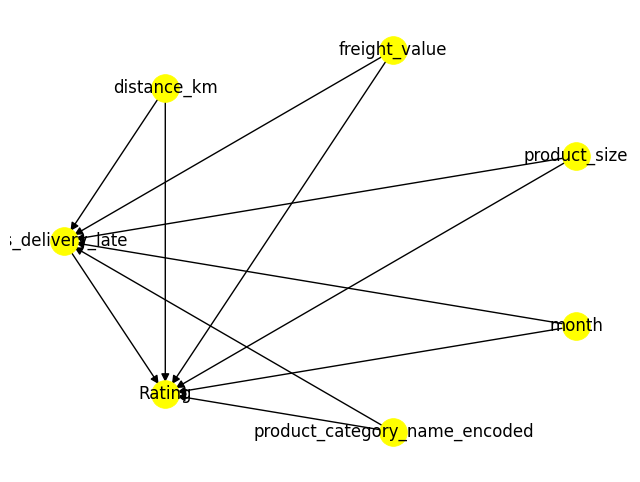

In [5]:
# 我们在模型中指定干预方法、结果和混杂因素。
model = CausalModel(
    data=df,
    treatment=treatment,
    outcome=outcome,
    common_causes=covariates
)

# 第 2 步：查看图形模型（可选）
model.view_model()

### 3.2 第 3 步：确定因果效应

In [6]:
# 指定如何估计因果效应。 这里我们使用倾向得分进行匹配。
identified_estimand = model.identify_effect()

### 3.3 第 4 步：利用倾向得分匹配估算干预效果

In [7]:
# 这将使用倾向得分匹配法（PSM）估算因果效应。
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    target_units="ate"
)

# 治疗组和对照组
treated = df.loc[df['is_delivery_late'] == 1]
control = df.loc[df['is_delivery_late'] == 0]

# 在控制倾向得分上拟合 KNN 算法
control_neighbors = NearestNeighbors(n_neighbors=1, algorithm="ball_tree").fit(
    control['propensity_score'].values.reshape(-1, 1)
)

# 为每个处理过的订单查找匹配项
distances, indices = control_neighbors.kneighbors(treated['propensity_score'].values.reshape(-1, 1))

att = 0
outcome_variable = 'Rating'
treated_outcomes = treated[outcome_variable]
control_outcomes = list(control.iloc[indices.flatten()][outcome_variable])

att = (treated_outcomes - control_outcomes).mean()
print("att: ", att)

propensity_score_matching
att:  -2.007871878393051


### 3.4 匹配时间

通过为每个订单分配倾向得分，我们可以根据相似的倾向得分将延迟交货（治疗组）与准时交货（对照组）进行匹配。此匹配过程旨在创建平衡的组，确保观察到的任何评级差异都可以直接归因于延迟交付的影响。

In [8]:
smd_before_lst = []

for i in covariates:
    t = df[df['is_delivery_late'] == 1][i]
    c = df[df['is_delivery_late'] == 0][i]

    # 在匹配前计算平均值和集合标准偏差
    mean_treated = t.mean()
    mean_control = c.mean()
    pooled_std = np.sqrt((t.var() + c.var()) / 2)

    smd_before = (mean_treated - mean_control) / pooled_std
    smd_before_lst.append(smd_before)
    
control_df = control.iloc[indices.flatten()][covariates]
treatment_df = treated.loc[treated.index][covariates]
control_df['is_treatment'] = 0
treatment_df['is_treatment'] = 1
matched_df = pd.concat([control_df, treatment_df])



smd_after_lst = []

for i in covariates:
    t = matched_df[matched_df['is_treatment'] == 1][i]
    c = matched_df[matched_df['is_treatment'] == 0][i]

    # 在匹配前计算平均值和集合标准偏差
    mean_treated = t.mean()
    mean_control = c.mean()
    pooled_std = np.sqrt((t.var() + c.var()) / 2)

    smd_after = (mean_treated - mean_control) / pooled_std
    smd_after_lst.append(smd_after)

### 3.5 评估匹配质量


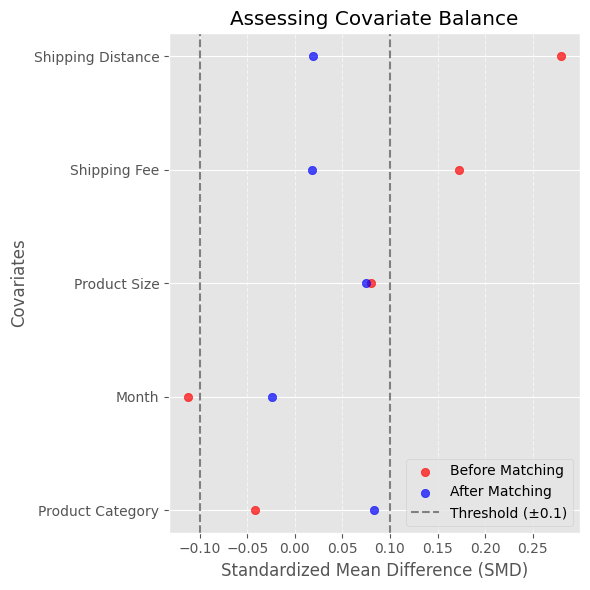

In [9]:
covariates_2 = ['Product Category', 'Month', 'Product Size', 'Shipping Fee', 'Shipping Distance']

plot_df = pd.DataFrame({'covariates': covariates_2,
 'smd_before': smd_before_lst,
 'smd_after': smd_after_lst})

# Plotting
plt.figure(figsize=(6, 6))
plt.scatter(plot_df['smd_before'], plot_df['covariates'], color='red', label='Before Matching', alpha=0.7)
plt.scatter(plot_df['smd_after'], plot_df['covariates'], color='blue', label='After Matching', alpha=0.7)
plt.axvline(x=0.1, color='gray', linestyle='--', label='Threshold (±0.1)')
plt.axvline(x=-0.1, color='gray', linestyle='--')

# Customizing the Plot
plt.xlabel('Standardized Mean Difference (SMD)')
plt.ylabel('Covariates')
plt.title('Assessing Covariate Balance')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Show Plot
plt.show()


该图显示匹配后对照和治疗之间的分布差异小很多，表明匹配良好。

### 3.6 估计影响

In [10]:
# 估计 ATC
treated = df.loc[df['is_delivery_late'] == 1]
control = df.loc[df['is_delivery_late'] == 0]

treated_neighbors = NearestNeighbors(n_neighbors=1, algorithm="ball_tree").fit(
    treated['propensity_score'].values.reshape(-1, 1)
)
distances, indices = treated_neighbors.kneighbors(control['propensity_score'].values.reshape(-1, 1))

atc = 0
outcome_variable = 'Rating'
control_outcomes = control[outcome_variable]
treated_outcomes = list(treated.iloc[indices.flatten()][outcome_variable])

atc = (treated_outcomes - control_outcomes).mean()

print("ATC: ", atc)

balance = check_for_dataset_balance(control_idx=control.index, treatment_idx=indices.flatten(), estimate_type='atc')
balance

ATC:  -1.8762759018544193


is_treatment                                     0              1
product_category_name_encoded count  107473.000000  107473.000000
                              mean       36.742680      37.613791
                              std        22.108333      22.372832
                              min         0.000000       0.000000
                              25%        13.000000      13.000000
                              50%        32.000000      33.000000
                              75%        55.000000      59.000000
                              max        72.000000      72.000000
month                         count  107473.000000  107473.000000
                              mean        6.057159       6.125632
                              std         3.197965       3.689889
                              min         1.000000       1.000000
                              25%         3.000000       3.000000
                              50%         6.000000       5.000000
                              75%         8.000000      10.000000
                              max        12.000000      12.000000
product_size                  count  107473.000000  107473.000000
                              mean    15144.000540   16469.051306
                              std     23144.479808   25209.650758
                              min       168.000000     352.000000
                              25%      2856.000000    2850.000000
                              50%      6552.000000    6480.000000
                              75%     18150.000000   19800.000000
                              max    296208.000000  269500.000000
freight_value                 count  107473.000000  107473.000000
                              mean       19.786251      20.450123
                              std        15.478152      14.954435
                              min         0.000000       0.000000
                              25%        12.930000      14.100000
                              50%        16.180000      16.790000
                              75%        21.040000      21.350000
                              max       409.680000     237.110000
distance_km                   count  107473.000000  107473.000000
                              mean      583.718524     598.018403
                              std       577.414843     565.650799
                              min         0.000000       0.000000
                              25%       176.547201     255.488041
                              50%       424.496622     440.161334
                              75%       776.605751     754.614439
                              max      5338.619521    8677.911622

ATE:  -1.8847188721797965
*** Causal Estimate ***

## Identified estimand
Estimand type: nonparametric-ate

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                                     ↪
───────────────────(E[Rating|month,distance_km,product_category_name_encoded,f ↪
d[is_delivery_late]                                                            ↪

↪                            
↪ reight_value,product_size])
↪                            
Estimand assumption 1, Unconfoundedness: If U→{is_delivery_late} and U→Rating then P(Rating|is_delivery_late,month,distance_km,product_category_name_encoded,freight_value,product_size,U) = P(Rating|is_delivery_late,month,distance_km,product_category_name_encoded,freight_value,product_size)

## Realized estimand
b: Rating~is_delivery_late+month+distance_km+product_category_name_encoded+freight_value+product_size
Target units: ate

## Estimate
Mean value: -1.8847188721797965

propensity_score_

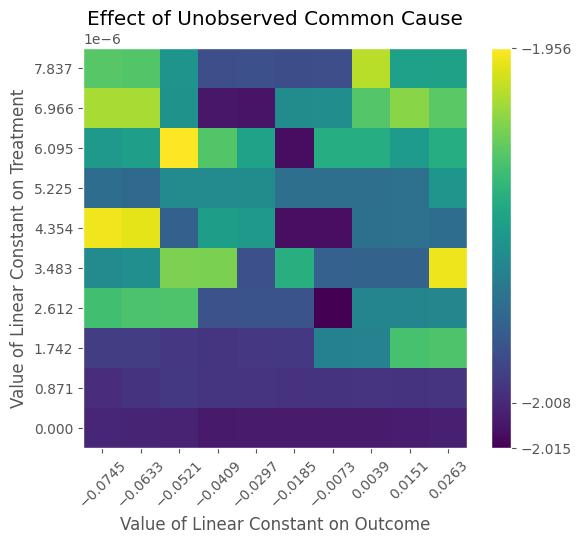

Refute: Add an Unobserved Common Cause
Estimated effect:-2.007871878393051
New effect:(np.float64(-2.014525903319761), np.float64(-1.9561657040092537))



In [11]:
numtreatedunits = treated.shape[0]
numcontrolunits = control.shape[0]
est = (att * numtreatedunits + atc * numcontrolunits) / (numtreatedunits + numcontrolunits)
print("ATE: ", est)

print(estimate)

# 使用倾向得分匹配（PSM）估算治疗效果
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    target_units="att"
)

# 显示因果估计值、置信区间和标准误差
print("Causal Estimate (ATT):", estimate.value)
print("Confidence Interval:", estimate.get_confidence_intervals(method='bootstrap'))

# 添加一个未观察到的混杂因素，看看治疗效果如何变化
refutation_unobserved_confounding = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="add_unobserved_common_cause"
)

# 显示反驳结果
print(refutation_unobserved_confounding)

propensity_score_matching
ATT (Average Treatment effect on the Treated): -2.007871878393051
propensity_score_matching
ATC (Average Treatment effect on the Controls): -1.8762759018544193


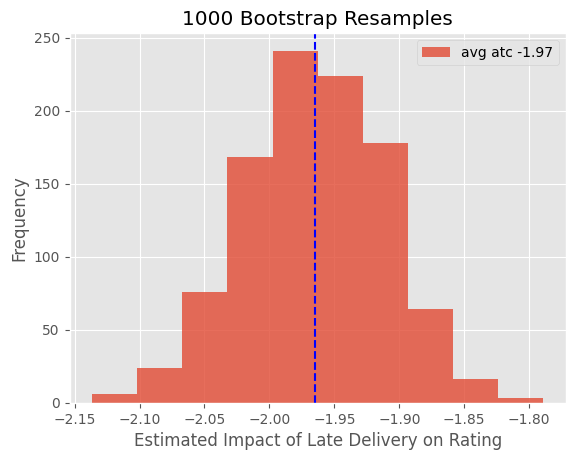

In [12]:
# 使用 DoWhy 估算 ATT
estimate_ATT = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    target_units="att"  
)

print("ATT (Average Treatment effect on the Treated):", estimate_ATT.value)

# Estimate ATC using DoWhy
estimate_ATC = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    target_units="atc"  
)


print("ATC (Average Treatment effect on the Controls):", estimate_ATC.value)

number_of_bootstraps = 1000
number_of_samples = 20000
att_lst = []

for i in range(number_of_bootstraps):

    df_sample = df.sample(n=number_of_samples)
    # 治疗组和对照组
    treated = df_sample.loc[df['is_delivery_late'] == 1]
    control = df_sample.loc[df['is_delivery_late'] == 0]

    # 在控制倾向得分上拟合 KNN 算法
    control_neighbors = NearestNeighbors(n_neighbors=1, algorithm="ball_tree").fit(
        control['propensity_score'].values.reshape(-1, 1)
    )

    # 为每个处理过的订单查找匹配项
    distances, indices = control_neighbors.kneighbors(treated['propensity_score'].values.reshape(-1, 1))

    att = 0
    outcome_variable = 'Rating'
    treated_outcomes = treated[outcome_variable]
    control_outcomes = list(control.iloc[indices.flatten()][outcome_variable])

    att = (treated_outcomes - control_outcomes).mean()

    att_lst.append(att)
    
plt.hist(att_lst, alpha=0.8, label=f'avg atc {round(np.mean(att_lst),2)}')
plt.axvline(np.mean(att_lst), ls='--', c='blue')
plt.xlabel("Estimated Impact of Late Delivery on Rating")
plt.ylabel("Frequency")
plt.title("1000 Bootstrap Resamples")
plt.legend()
plt.show()

## 四、结论

在控制可观测协变量并通过 PSM 匹配后，延迟交付对满意度存在稳定的负向因果影响（ATT≈−2.01，95%CI[−2.08, −1.99]）。